In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/raw/HAM10000_metadata.csv")
print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [5]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

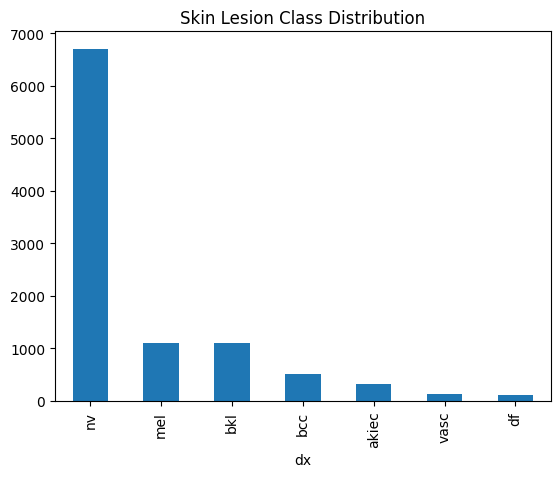

In [6]:
df['dx'].value_counts().plot(kind='bar')
plt.title('Skin Lesion Class Distribution')
plt.show()

In [8]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma',
    'bkl': 'Benign keratosis-like lesions'
}

df['cell_type'] = df['dx'].map(lesion_type_dict)

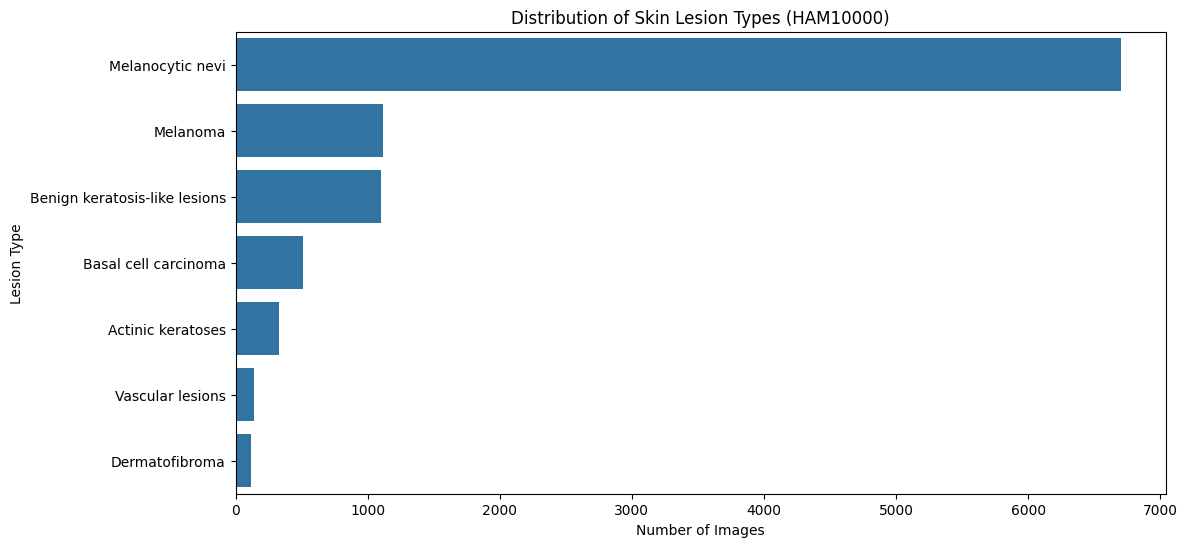

cell_type
Melanocytic nevi                 6705
Melanoma                         1113
Benign keratosis-like lesions    1099
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64


In [9]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index)
plt.title('Distribution of Skin Lesion Types (HAM10000)')
plt.xlabel('Number of Images')
plt.ylabel('Lesion Type')
plt.savefig("class_imbalance.jpg", dpi=300, bbox_inches="tight")
plt.show()

print(df['cell_type'].value_counts())

In [10]:
from sklearn.model_selection import train_test_split

df_train_val, df_test = train_test_split(
    df, 
    test_size=0.1, 
    random_state=42, 
    stratify=df['dx']
)

df_train, df_val = train_test_split(
    df_train_val, 
    test_size=0.111, 
    random_state=42, 
    stratify=df_train_val['dx']
)

print(f"Train size: {len(df_train)}")
print(f"Val size: {len(df_val)}")
print(f"Test size: {len(df_test)}")

Train size: 8012
Val size: 1001
Test size: 1002


In [11]:
print("Training Distribution:\n", df_train['dx'].value_counts(normalize=True))
print("\nValidation Distribution:\n", df_val["dx"].value_counts(normalize=True))
print("\nTesting Distribution:\n", df_test['dx'].value_counts(normalize=True))

Training Distribution:
 dx
nv       0.669496
mel      0.111208
bkl      0.109710
bcc      0.051423
akiec    0.032576
vasc     0.014229
df       0.011358
Name: proportion, dtype: float64

Validation Distribution:
 dx
nv       0.669331
mel      0.110889
bkl      0.109890
bcc      0.050949
akiec    0.032967
vasc     0.013986
df       0.011988
Name: proportion, dtype: float64

Testing Distribution:
 dx
nv       0.669661
mel      0.110778
bkl      0.109780
bcc      0.050898
akiec    0.032934
vasc     0.013972
df       0.011976
Name: proportion, dtype: float64


In [25]:
import shutil
import os

def copy_images_to_folders(df, subset_name):
    base_source = '/Users/emiryscn/repos/multi-class-skin-lesion-detection/data/raw/ham10000_images/'
    base_dest = f'/Users/emiryscn/repos/multi-class-skin-lesion-detection/data/processed/{subset_name}/'
    
    for _, row in df.iterrows():
        image_name = row['image_id'] + '.jpg'
        label = row['dx']
        
        source = os.path.join(base_source, image_name)
        destination = os.path.join(base_dest, label, image_name)
        
        if os.path.exists(source):
            shutil.copy(source, destination)

copy_images_to_folders(df_train, 'train')
copy_images_to_folders(df_val, 'val')
copy_images_to_folders(df_test, 'test')

print("Dataset successfully organized!")

Dataset successfully organized!


In [26]:
processed_path = '/Users/emiryscn/repos/multi-class-skin-lesion-detection/data/processed/'
for split in ['train', 'val', 'test']:
    print(f"--- {split.upper()} SET ---")
    for cls in os.listdir(os.path.join(processed_path, split)):
        if not cls.startswith('.'): # Skip hidden files
            count = len(os.listdir(os.path.join(processed_path, split, cls)))
            print(f"{cls}: {count} images")

--- TRAIN SET ---
akiec: 261 images
df: 91 images
bkl: 879 images
vasc: 114 images
nv: 5364 images
bcc: 412 images
mel: 891 images
--- VAL SET ---
akiec: 33 images
df: 12 images
bkl: 110 images
vasc: 14 images
nv: 670 images
bcc: 51 images
mel: 111 images
--- TEST SET ---
akiec: 33 images
df: 12 images
bkl: 110 images
vasc: 14 images
nv: 671 images
bcc: 51 images
mel: 111 images


In [12]:
import wandb

# test run
wandb.init(
    project="ham10000-capstone",
    name="test-run",
    config={
        "test": True,
        "architecture": "ResNet50",
        "img_size": 224,
    }
)

wandb.log({"test_accuracy": 0.85})

wandb.finish()

print("wb is working, dashboard at https://wandb.ai")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/emiryscn/.netrc.
wandb: Currently logged in as: emiryscn (emiryscn-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


test_accuracy,▁
test_accuracy,0.85


wb is working, dashboard at https://wandb.ai
